Shuffle 1: Accuracy(RMSEtest*(1-R2)): 0.0390, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2962
Shuffle 2: Accuracy(RMSEtest*(1-R2)): 0.0305, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2683
Shuffle 3: Accuracy(RMSEtest*(1-R2)): 0.0674, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2420
Shuffle 4: Accuracy(RMSEtest*(1-R2)): 0.0297, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2917
Shuffle 5: Accuracy(RMSEtest*(1-R2)): 0.0372, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2685
Shuffle 6: Accuracy(RMSEtest*(1-R2)): 0.0579, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2764
Shuffle 7: Accuracy(RMSEtest*(1-R2)): 0.0497, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2483
Shuffle 8: Accuracy(RMSEtest*(1-R2)): 0.0240, Optimized RBF Length Scale: 11.0, Optimized WhiteKernel noise level: 0.2936
Shuffle 9: Accuracy(RMSE

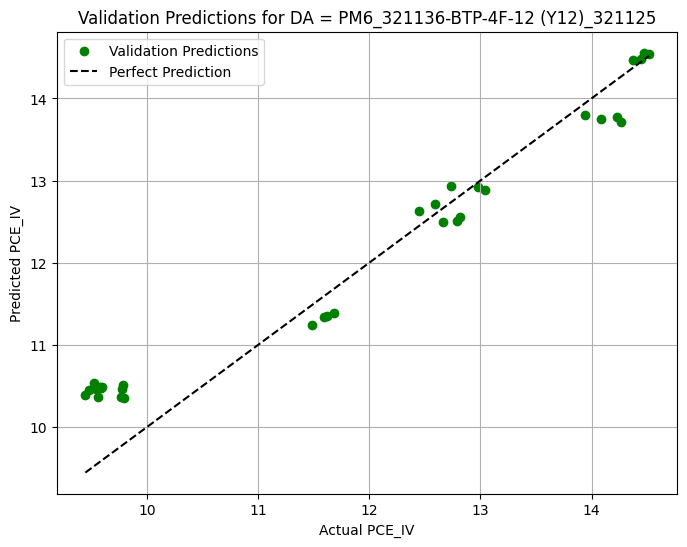

Best model accuracy (RMSE*(1-R2)): 0.0239813
Validation RMSE: 0.5499, Validation R²: 0.9159, Validation MAPE: 4.2433%


In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import math

import warnings
from sklearn.exceptions import ConvergenceWarning
# Suppress specific warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)



def split_by_DA(df, da_value):
    train_df = df[df['DA'] != da_value].copy()
    val_df = df[df['DA'] == da_value].copy()
    return train_df, val_df
def standadize(X):
    X = np.array(X)
    X_m = np.mean(X, axis=0)
    X_s = np.std(X, axis=0)
    X -= X_m
    X /= X_s
    return X, X_m, X_s  # Return mean and std for unstandardization

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def train_and_validate_by_DA_with_shuffles(df, feature_columns, target_column, da_value, shuffle_times=5, test_size=0.25, fixed_length_scale=False, kernel_length_scale=11.0):
    # Split into training and validation sets
    train_df, val_df = split_by_DA(df, da_value)

    # Extract features and target for training
    X_train = train_df[feature_columns].values.astype(float)
    y_train = train_df[target_column].values.astype(float)

    # Extract features and target for validation
    X_val = val_df[feature_columns].values.astype(float)
    y_val = val_df[target_column].values.astype(float)

    # Standardize training data
    X_train, X_m, X_s = standadize(X_train)
    X_val = (X_val - X_m) / X_s

    # Kernel Definition
    optimizer_setting = 'fmin_l_bfgs_b'
    noise_level = 1e-1

    if fixed_length_scale:
        kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=kernel_length_scale, length_scale_bounds='fixed') + WhiteKernel(noise_level=noise_level, noise_level_bounds=(1e-10, 0.5))
        optimizer_setting = None
    else:
        kernel = 1* RBF(length_scale=kernel_length_scale, length_scale_bounds=(11, 100)) + WhiteKernel(noise_level=noise_level, noise_level_bounds=(0.1, 10))
#C(1000.0, (1e-3, 1e8))
    # Initialize variables to track the best model
    best_accuracy = float('inf')
    best_gpr = None

    # Loop over shuffles
    for shuffle in range(shuffle_times):
        # Split the training data
        X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
            X_train, y_train, test_size=test_size, random_state=None
        )

        # Train the model
        gpr = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=20,
            optimizer=optimizer_setting,
            random_state=42,
            normalize_y=False,
            alpha=0.0
        )
        gpr.fit(X_train_split, y_train_split)

        # Print optimized kernel parameters
        #print(f"Shuffle {shuffle + 1}:")
        # Access the optimized kernel
        optimized_kernel = gpr.kernel_
        
        # Extract the constant kernel value
        length_scale = optimized_kernel.k1.k2.length_scale
        noise_level = optimized_kernel.k2.noise_level
        #print("---")

        # Evaluate on the test set
        y_pred_test = gpr.predict(X_test_split)
        rmse_test = np.sqrt(mean_squared_error(y_test_split, y_pred_test))
        r2_test = r2_score(y_test_split, y_pred_test)
        
        current_accuracy = rmse_test * (1 - r2_test)
        
        print(f"Shuffle {shuffle + 1}: Accuracy(RMSEtest*(1-R2)): {current_accuracy:.4f}, Optimized RBF Length Scale: {length_scale:.1f}, Optimized WhiteKernel noise level: {noise_level:.4f}")

        # Update best model
        if current_accuracy < best_accuracy:
            best_accuracy = current_accuracy
            best_gpr = gpr

    # Use the best model to evaluate on the validation set
    y_pred_val = best_gpr.predict(X_val)

    # Calculate metrics for validation set
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2_val = r2_score(y_val, y_pred_val)
    mape_val = mean_absolute_percentage_error(y_val, y_pred_val)
    
    # Plot results
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val, y_pred_val, color='green', label='Validation Predictions')
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], '--k', label='Perfect Prediction')
    plt.xlabel("Actual " + target_column)
    plt.ylabel("Predicted " + target_column)
    plt.title(f"Validation Predictions for DA = {da_value}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return rmse_val, r2_val, mape_val, y_val, y_pred_val, best_accuracy

############## Read in data
current_dir = os.getcwd()  # Gets the current working directory
file_name = "_Dataset Limited + Int - newTry - NewD18CL.csv"

df = pd.read_csv(os.path.join(current_dir, file_name))
target_column = "PCE_IV"
feature_columns = ['features_A.1a.w_UV', 'features_D.1a.w_UV', 'features_D_UV', 'features_Atot_UV', 'features_D.1a.c_UV']
ExcludeAndPredict = "PM6_321136-BTP-4F-12 (Y12)_321125"


rmse_val, r2_val, mape_val, y_val, y_pred_val, best_accuracy = train_and_validate_by_DA_with_shuffles(df, feature_columns, target_column, ExcludeAndPredict, shuffle_times=20)
print(f"Best model accuracy (RMSE*(1-R2)): {best_accuracy:.7f}")
print(f"Validation RMSE: {rmse_val:.4f}, Validation R²: {r2_val:.4f}, Validation MAPE: {mape_val:.4f}%")